In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import savgol_filter
import sys
sys.path.append('src')

clean_signals = np.load('data/simulated_clean/signals.npy')
noisy_signals = np.load('data/simulated_noisy/signals_noisy.npy')
freq_axis = np.load('data/simulated_clean/freq_axis.npy')

print(f"Clean  : {clean_signals.shape}")
print(f"Noisy  : {noisy_signals.shape}")

Clean  : (1000, 512)
Noisy  : (1000, 512)


In [3]:
def wavelet_denoise(signal, wavelet='db4', level=4, threshold_mode='soft'):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    threshold = np.sqrt(2 * np.log(len(signal))) * np.median(np.abs(coeffs[-1])) / 0.6745
    coeffs_thresh = [pywt.threshold(c, threshold, mode=threshold_mode) for c in coeffs]
    return pywt.waverec(coeffs_thresh, wavelet).astype(np.float32)

def savgol_denoise(signal, window=11, polyorder=3):
    return savgol_filter(signal, window_length=window, polyorder=polyorder).astype(np.float32)

idx = 0
wavelet_denoised = wavelet_denoise(noisy_signals[idx])
savgol_denoised  = savgol_denoise(noisy_signals[idx])

print("Wavelet denoised shape :", wavelet_denoised.shape)
print("SavGol denoised shape  :", savgol_denoised.shape)

Wavelet denoised shape : (512,)
SavGol denoised shape  : (512,)


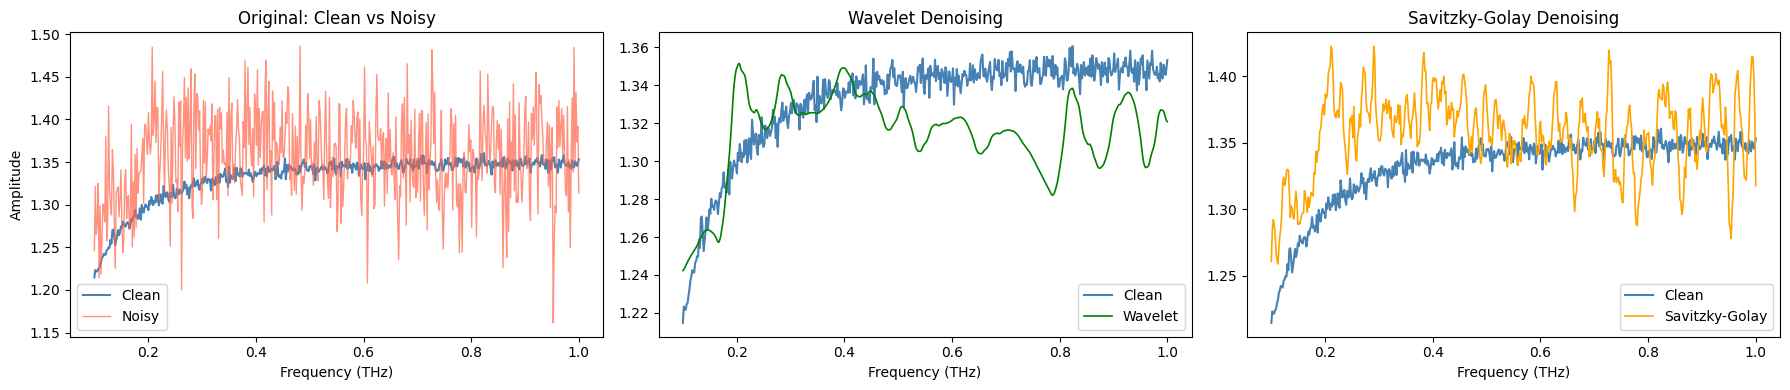

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(freq_axis, clean_signals[idx], color='steelblue', linewidth=1.5, label='Clean')
axes[0].plot(freq_axis, noisy_signals[idx], color='tomato', linewidth=1, alpha=0.7, label='Noisy')
axes[0].set_title('Original: Clean vs Noisy')
axes[0].set_xlabel('Frequency (THz)')
axes[0].set_ylabel('Amplitude')
axes[0].legend()

axes[1].plot(freq_axis, clean_signals[idx], color='steelblue', linewidth=1.5, label='Clean')
axes[1].plot(freq_axis, wavelet_denoised, color='green', linewidth=1.2, label='Wavelet')
axes[1].set_title('Wavelet Denoising')
axes[1].set_xlabel('Frequency (THz)')
axes[1].legend()

axes[2].plot(freq_axis, clean_signals[idx], color='steelblue', linewidth=1.5, label='Clean')
axes[2].plot(freq_axis, savgol_denoised, color='orange', linewidth=1.2, label='Savitzky-Golay')
axes[2].set_title('Savitzky-Golay Denoising')
axes[2].set_xlabel('Frequency (THz)')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/figures/03_classical_denoising.png', dpi=150)
plt.show()

In [5]:
def compute_snr(clean, denoised):
    signal_power = np.mean(clean ** 2)
    noise_power  = np.mean((clean - denoised) ** 2)
    return 10 * np.log10(signal_power / noise_power)

def compute_rmse(clean, denoised):
    return np.sqrt(np.mean((clean - denoised) ** 2))

wavelet_snr  = compute_snr(clean_signals[idx], wavelet_denoised)
wavelet_rmse = compute_rmse(clean_signals[idx], wavelet_denoised)

savgol_snr   = compute_snr(clean_signals[idx], savgol_denoised)
savgol_rmse  = compute_rmse(clean_signals[idx], savgol_denoised)

noisy_snr    = compute_snr(clean_signals[idx], noisy_signals[idx])
noisy_rmse   = compute_rmse(clean_signals[idx], noisy_signals[idx])

print(f"{'Method':<20} {'SNR (dB)':<15} {'RMSE':<10}")
print(f"{'-'*45}")
print(f"{'Noisy (baseline)':<20} {noisy_snr:<15.2f} {noisy_rmse:<10.4f}")
print(f"{'Wavelet':<20} {wavelet_snr:<15.2f} {wavelet_rmse:<10.4f}")
print(f"{'Savitzky-Golay':<20} {savgol_snr:<15.2f} {savgol_rmse:<10.4f}")

Method               SNR (dB)        RMSE      
---------------------------------------------
Noisy (baseline)     27.17           0.0583    
Wavelet              33.15           0.0293    
Savitzky-Golay       30.45           0.0400    


In [6]:
wavelet_all = np.array([wavelet_denoise(sig) for sig in noisy_signals])
savgol_all  = np.array([savgol_denoise(sig)  for sig in noisy_signals])

import os
os.makedirs('data/processed', exist_ok=True)
np.save('data/processed/wavelet_denoised.npy', wavelet_all)
np.save('data/processed/savgol_denoised.npy',  savgol_all)

print(f"Wavelet all : {wavelet_all.shape}")
print(f"SavGol all  : {savgol_all.shape}")
print("Saved to data/processed/")

Wavelet all : (1000, 512)
SavGol all  : (1000, 512)
Saved to data/processed/
